# Hyperparameters experimenting stable-baselines - Experiments on one agent using PettingZoo

In this notebook, different values of the gamma and learning_rate hyperparameters are being examined during the learning process.

The **learning rate** controls how quickly the model is adapted to the problem. Smaller learning rates require more training epochs given the smaller changes made to the weights each update, whereas larger learning rates result in rapid changes and require fewer training epochs.

**Gamma** is the discount factor. It quantifies how much importance we give for future rewards. Gamma varies from 0 to 1. If gamma is closer to zero, the agent will tend to consider only immediate rewards.

## Experiment Summary

- **Paths:** Three distinct routes considered for each origin-destination pair.
- **Network Architecture:** Utilization of the Csomor network.
- **Agents:** Altruistic.
- **Reinforcement Learning Algorithm:** Proximal Policy Optimization (PPO)

    - **PPO Hyperparameters:**
        - *Gamma:* 0 - 1
        - *Learning Rate:* 0 - 1


In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import matplotlib.pyplot as plt
import numpy as np

from utilities import confirm_env_variable
from utilities import get_params
import time
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [9]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [72.9845857965175, 348.26395128541947, 122.82738143980828], (0, 1): [588.9185964450786, 89.07185012233826, 353.2218136204669], (1, 0): [66.17387881921402, 443.0392543337574, 14.359663988581811], (1, 1): [84.66483772774772, 37.953617176128056, 72.76182354615983]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 0 and destination 1.


In [19]:
env.reset()
env.reward_table = []
env.actions = []

In [11]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

### Gamma

In [12]:
# Define the parameter ranges you want to test
gamma_range = np.linspace(0, 1, 10) 
times = []

In [15]:
for gamma in gamma_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": 1e-3,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=1, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    start_time = time.time()
    model.learn(total_timesteps=100) 
    execution_time = time.time() - start_time
    times.append(execution_time)

Using cpu device
---------------------------
| time/              |    |
|    fps             | 0  |
|    iterations      | 1  |
|    time_elapsed    | 71 |
|    total_timesteps | 10 |
---------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 0             |
|    iterations           | 2             |
|    time_elapsed         | 121           |
|    total_timesteps      | 20            |
| train/                  |               |
|    approx_kl            | 0.00087911484 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | 0.000223      |
|    learning_rate        | 0.001         |
|    loss                 | 2.31e+05      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0187       |
|    value_loss           | 4.62e+05      |
---------------------------------------

Reward table is:  [-756.6333333333333, -451.81666666666666, -756.6333333333333, -756.6333333333333, -756.6333333333333, -756.6333333333333, -756.6333333333333, -756.6333333333333, -451.81666666666666, -451.81666666666666, -451.81666666666666, -451.81666666666666, -451.81666666666666, -756.6333333333333, -451.81666666666666, -114.51666666666667, -451.81666666666666, -114.51666666666667, -756.6333333333333, -451.81666666666666, -756.6333333333333, -451.81666666666666, -756.6333333333333, -451.81666666666666, -114.51666666666667, -451.81666666666666, -756.6333333333333, -114.51666666666667, -114.51666666666667, -114.51666666666667, -114.51666666666667, -756.6333333333333, -451.81666666666666, -451.81666666666666, -114.51666666666667, -451.81666666666666, -451.81666666666666, -756.6333333333333, -451.81666666666666, -451.81666666666666, -114.51666666666667, -451.81666666666666, -114.51666666666667, -114.51666666666667, -114.51666666666667, -451.81666666666666, -451.81666666666666, -451.816

c:\Users\Anastasia\Documents\Milestone-One-Petting-Zoo\environment.py:225: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


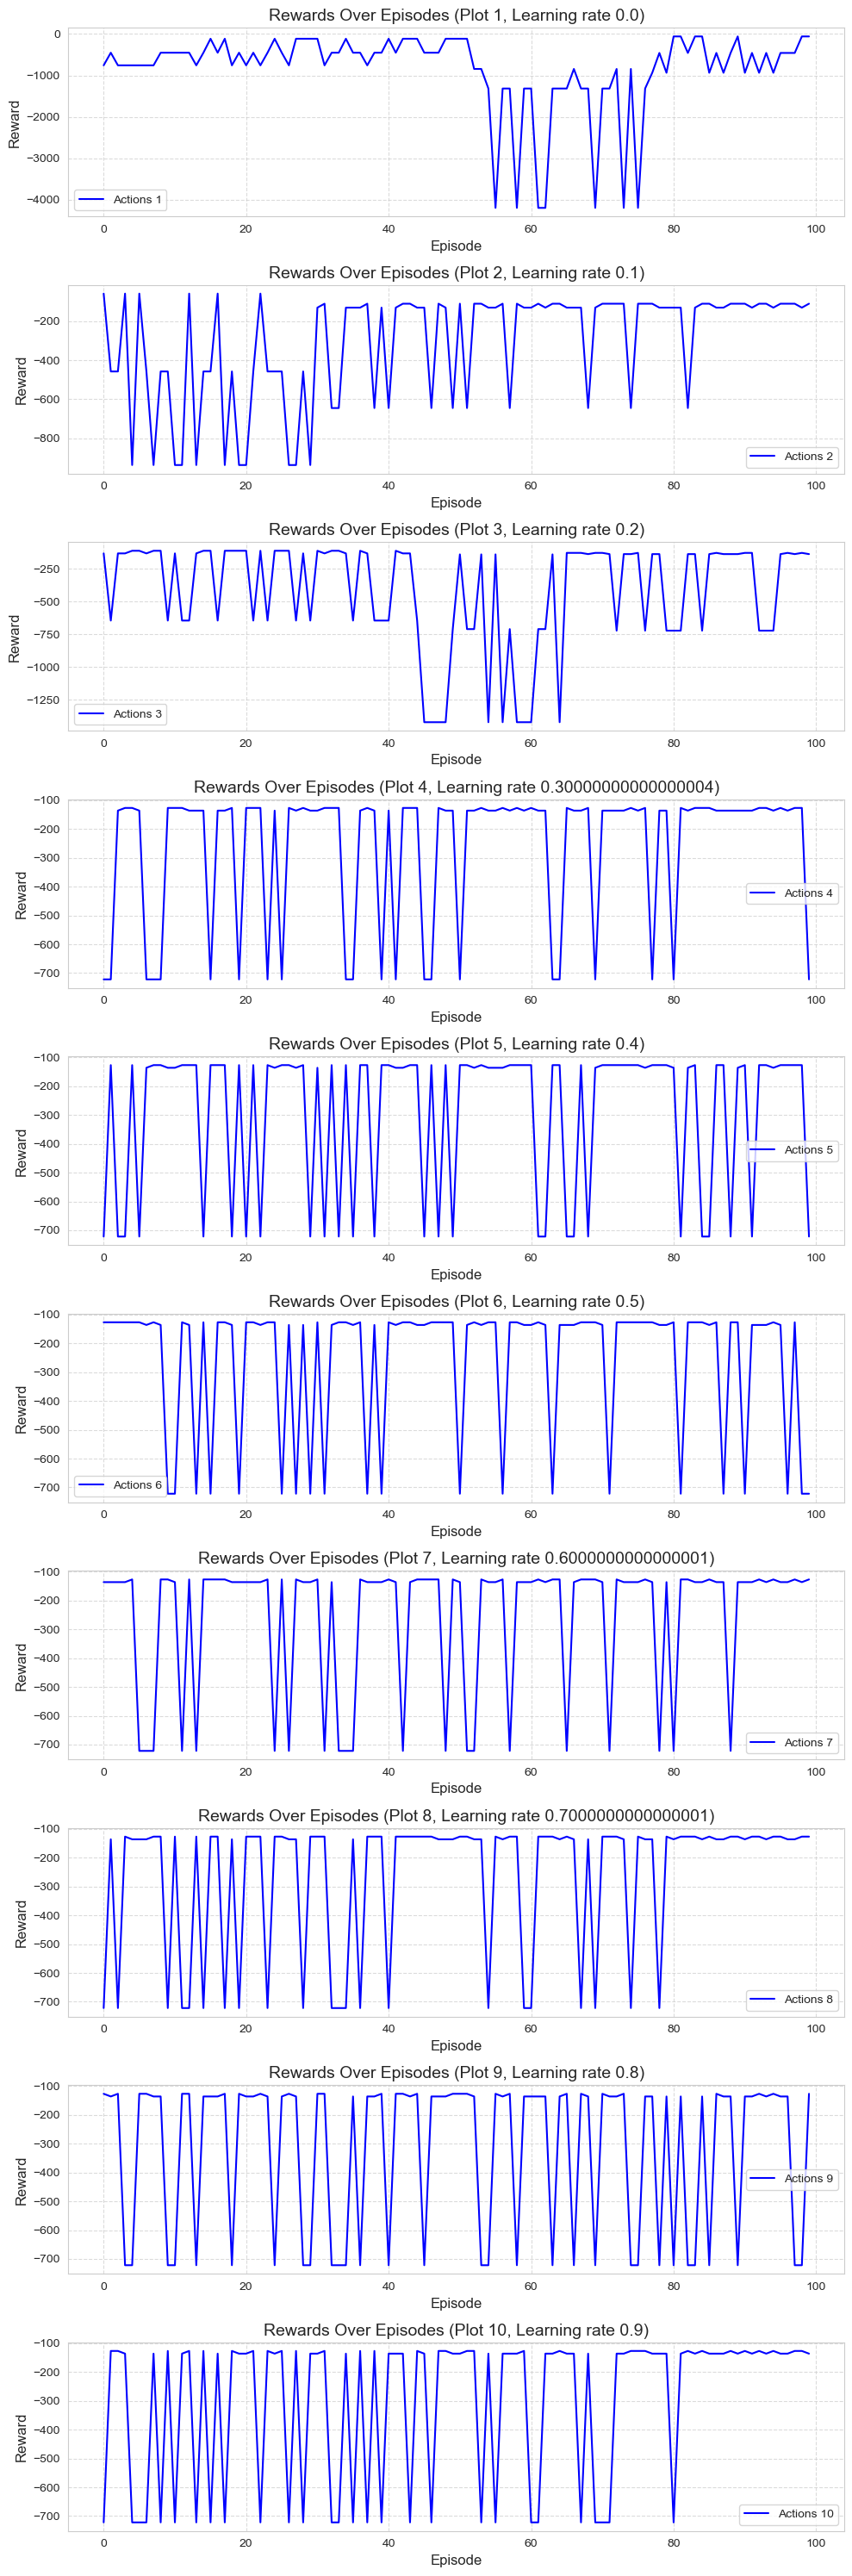

c:\Users\Anastasia\Documents\Milestone-One-Petting-Zoo\environment.py:262: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


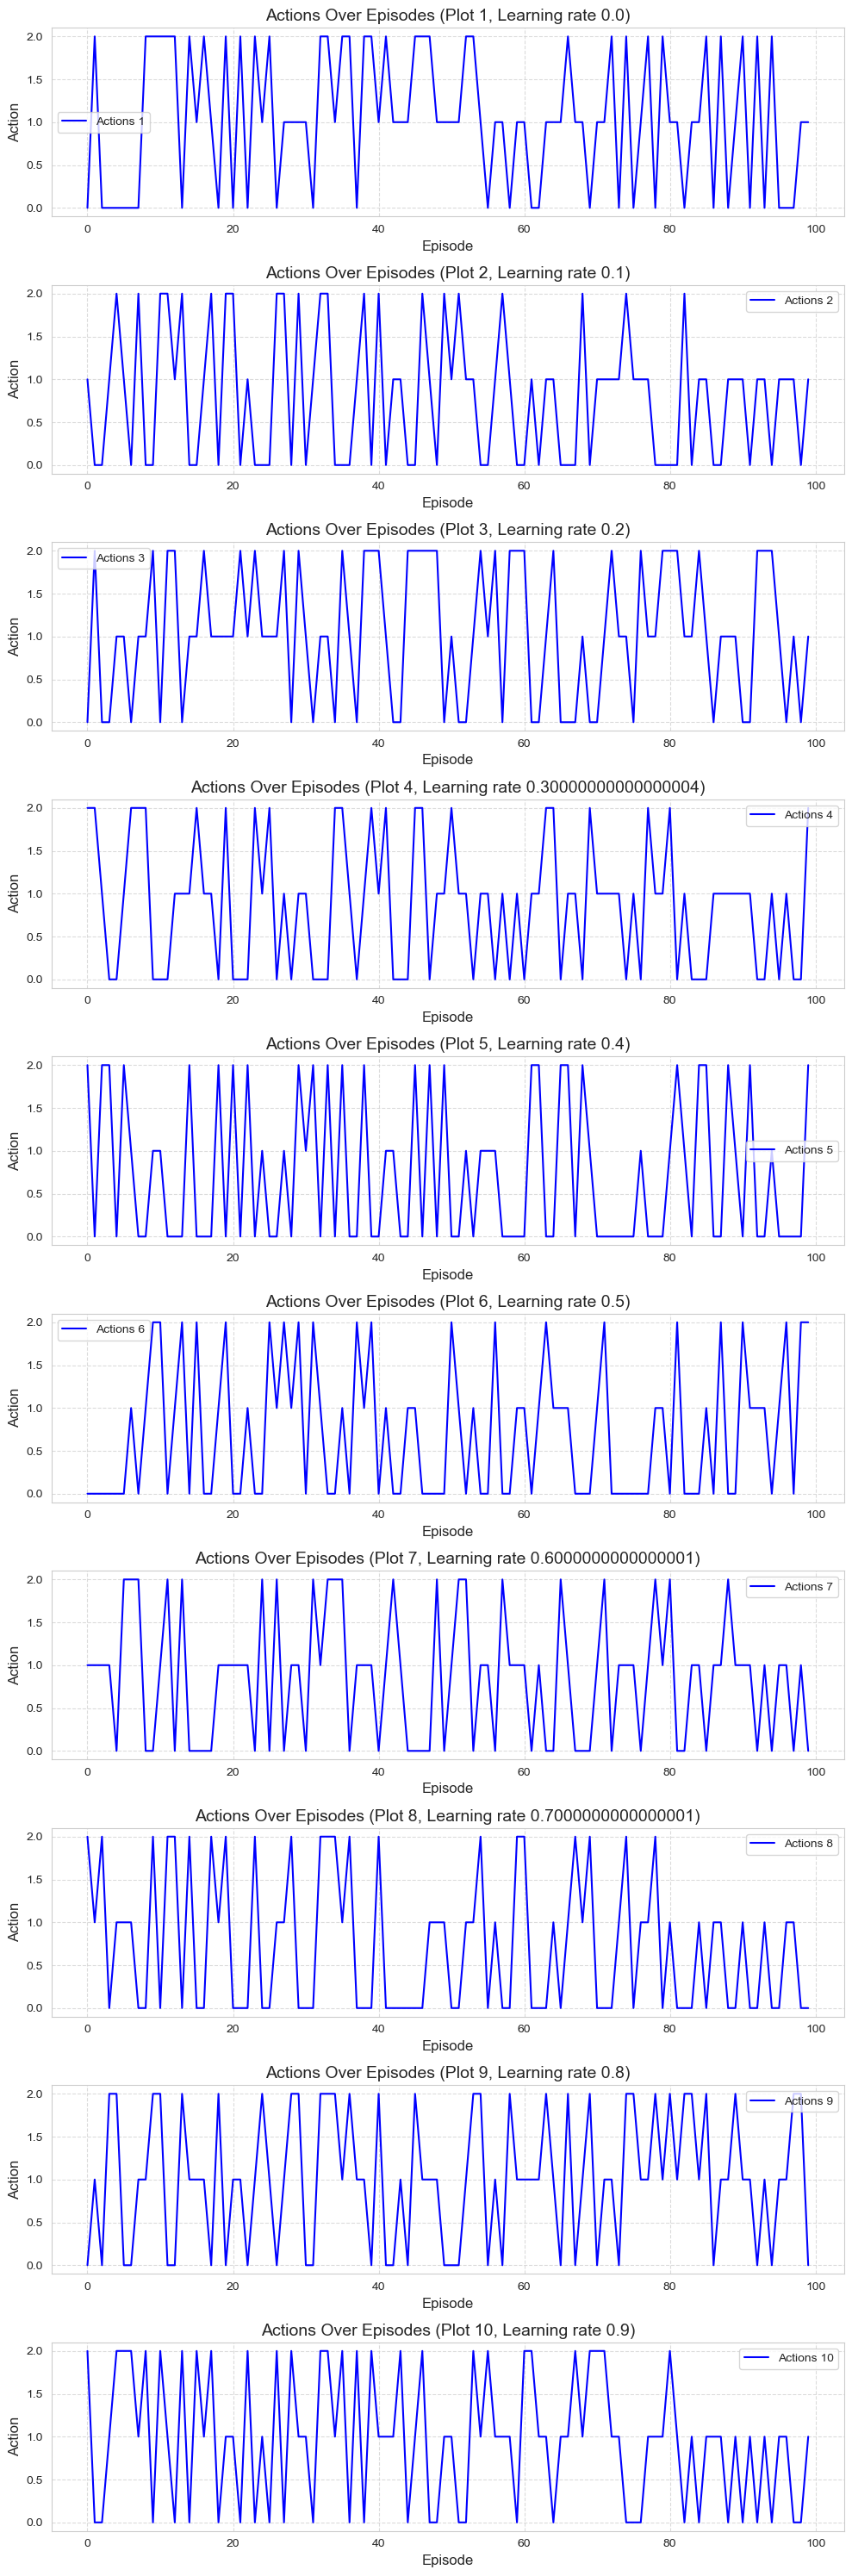

In [16]:
env.close()

### Comments on the plots

Regarding the reward plots, observations suggest that for gamma values of 0.1, 0.2, and 0.3, the agent does not approach the minimum reward threshold of -100. This phenomenon may arise due to the emphasis placed on immediate rewards with smaller gamma values, potentially fostering more cautious behaviors.

However, when examining the action plots, conclusive insights regarding the influence of gamma values on learning convergence or speed cannot be derived.

#### Focus on the 0 - 0.1

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [44.64320235449446, 169.07312265438992, 62.23360925645666], (0, 1): [33.12503923095517, 58.42993962163704, 47.64799933461604], (1, 0): [105.21121875072416, 17.947755091192626, 213.70230438655], (1, 1): [3616.8440529736154, 333.56206238461505, 146.38864186761725]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 1.


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [6]:
gamma_range = [1e-1, 1e-2, 1e-3] 
times = []

In [7]:
for gamma in gamma_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": 1e-3,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=1, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    start_time = time.time()
    model.learn(total_timesteps=1000) 
    execution_time = time.time() - start_time
    times.append(execution_time)

Using cpu device
----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 382 |
|    total_timesteps | 10  |
----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 0             |
|    iterations           | 2             |
|    time_elapsed         | 504           |
|    total_timesteps      | 20            |
| train/                  |               |
|    approx_kl            | 0.00043631197 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | 7.3e-05       |
|    learning_rate        | 0.001         |
|    loss                 | 5.07e+06      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0126       |
|    value_loss           | 1.01e+07      |
--------------------------------

NameError: name 'times' is not defined

Reward table is:  [-4496.266666666666, -4496.266666666666, -4496.266666666666, -444.1333333333333, -4496.266666666666, -199.45, -4496.266666666666, -199.45, -199.45, -199.45, -444.1333333333333, -199.45, -199.45, -444.1333333333333, -199.45, -444.1333333333333, -199.45, -199.45, -4496.266666666666, -199.45, -4496.266666666666, -199.45, -444.1333333333333, -4496.266666666666, -199.45, -199.45, -444.1333333333333, -199.45, -4496.266666666666, -444.1333333333333, -444.1333333333333, -444.1333333333333, -199.45, -4496.266666666666, -4496.266666666666, -444.1333333333333, -4496.266666666666, -4496.266666666666, -444.1333333333333, -199.45, -444.1333333333333, -199.45, -199.45, -199.45, -4496.266666666666, -199.45, -199.45, -444.1333333333333, -199.45, -444.1333333333333, -4496.266666666666, -4496.266666666666, -444.1333333333333, -4496.266666666666, -444.1333333333333, -199.45, -199.45, -4496.266666666666, -444.1333333333333, -199.45, -444.1333333333333, -199.45, -199.45, -199.45, -4496.266

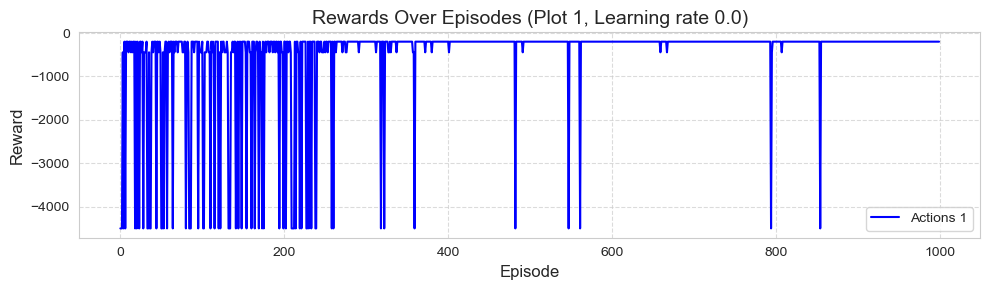

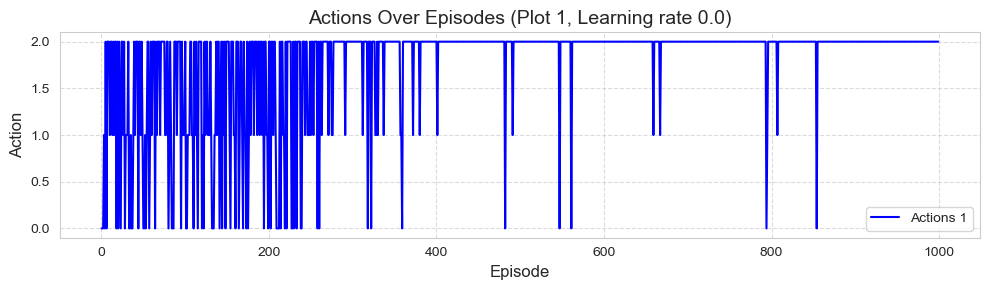

In [8]:
env.close()

### Learning Rate

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1931.6308078145244, 42.81432856419492, 174.653087081107], (0, 1): [41.785358472880446, 185.35153528205154, 2627.4815044957236], (1, 0): [409.5222634166687, 53.08450290023413, 10.192491526817527], (1, 1): [15.003931219716113, 326.9815873230122, 973.3484939464905]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 0 and destination 0.


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [6]:
learning_rate_range = np.linspace(0, 1, 10)  # Example range for learning_rate
gamma = 0.95  # Constant value for gamma

In [7]:
for learning_rate in learning_rate_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": learning_rate,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=1, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    model.learn(total_timesteps=100)  # Example: 100 total timesteps

Using cpu device
----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 191 |
|    total_timesteps | 10  |
----------------------------
---------------------------------------
| time/                   |           |
|    fps                  | 0         |
|    iterations           | 2         |
|    time_elapsed         | 273       |
|    total_timesteps      | 20        |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | -1.1      |
|    explained_variance   | 4.59e-06  |
|    learning_rate        | 0         |
|    loss                 | 1.73e+06  |
|    n_updates            | 10        |
|    policy_gradient_loss | -1.79e-09 |
|    value_loss           | 3.45e+06  |
---------------------------------------
---------------------------------------
| time/             

Reward table is:  [-221.13333333333333, -2395.8333333333335, -2395.8333333333335, -2395.8333333333335, -2395.8333333333335, -54.166666666666664, -2395.8333333333335, -221.13333333333333, -54.166666666666664, -2395.8333333333335, -54.166666666666664, -221.13333333333333, -221.13333333333333, -221.13333333333333, -54.166666666666664, -2395.8333333333335, -54.166666666666664, -54.166666666666664, -2395.8333333333335, -54.166666666666664, -221.13333333333333, -2395.8333333333335, -54.166666666666664, -221.13333333333333, -54.166666666666664, -221.13333333333333, -221.13333333333333, -2395.8333333333335, -221.13333333333333, -54.166666666666664, -2395.8333333333335, -54.166666666666664, -2395.8333333333335, -221.13333333333333, -54.166666666666664, -221.13333333333333, -54.166666666666664, -221.13333333333333, -2395.8333333333335, -54.166666666666664, -54.166666666666664, -221.13333333333333, -221.13333333333333, -221.13333333333333, -2395.8333333333335, -54.166666666666664, -221.1333333333

c:\Users\Anastasia\Documents\Milestone-One-Petting-Zoo\environment.py:225: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


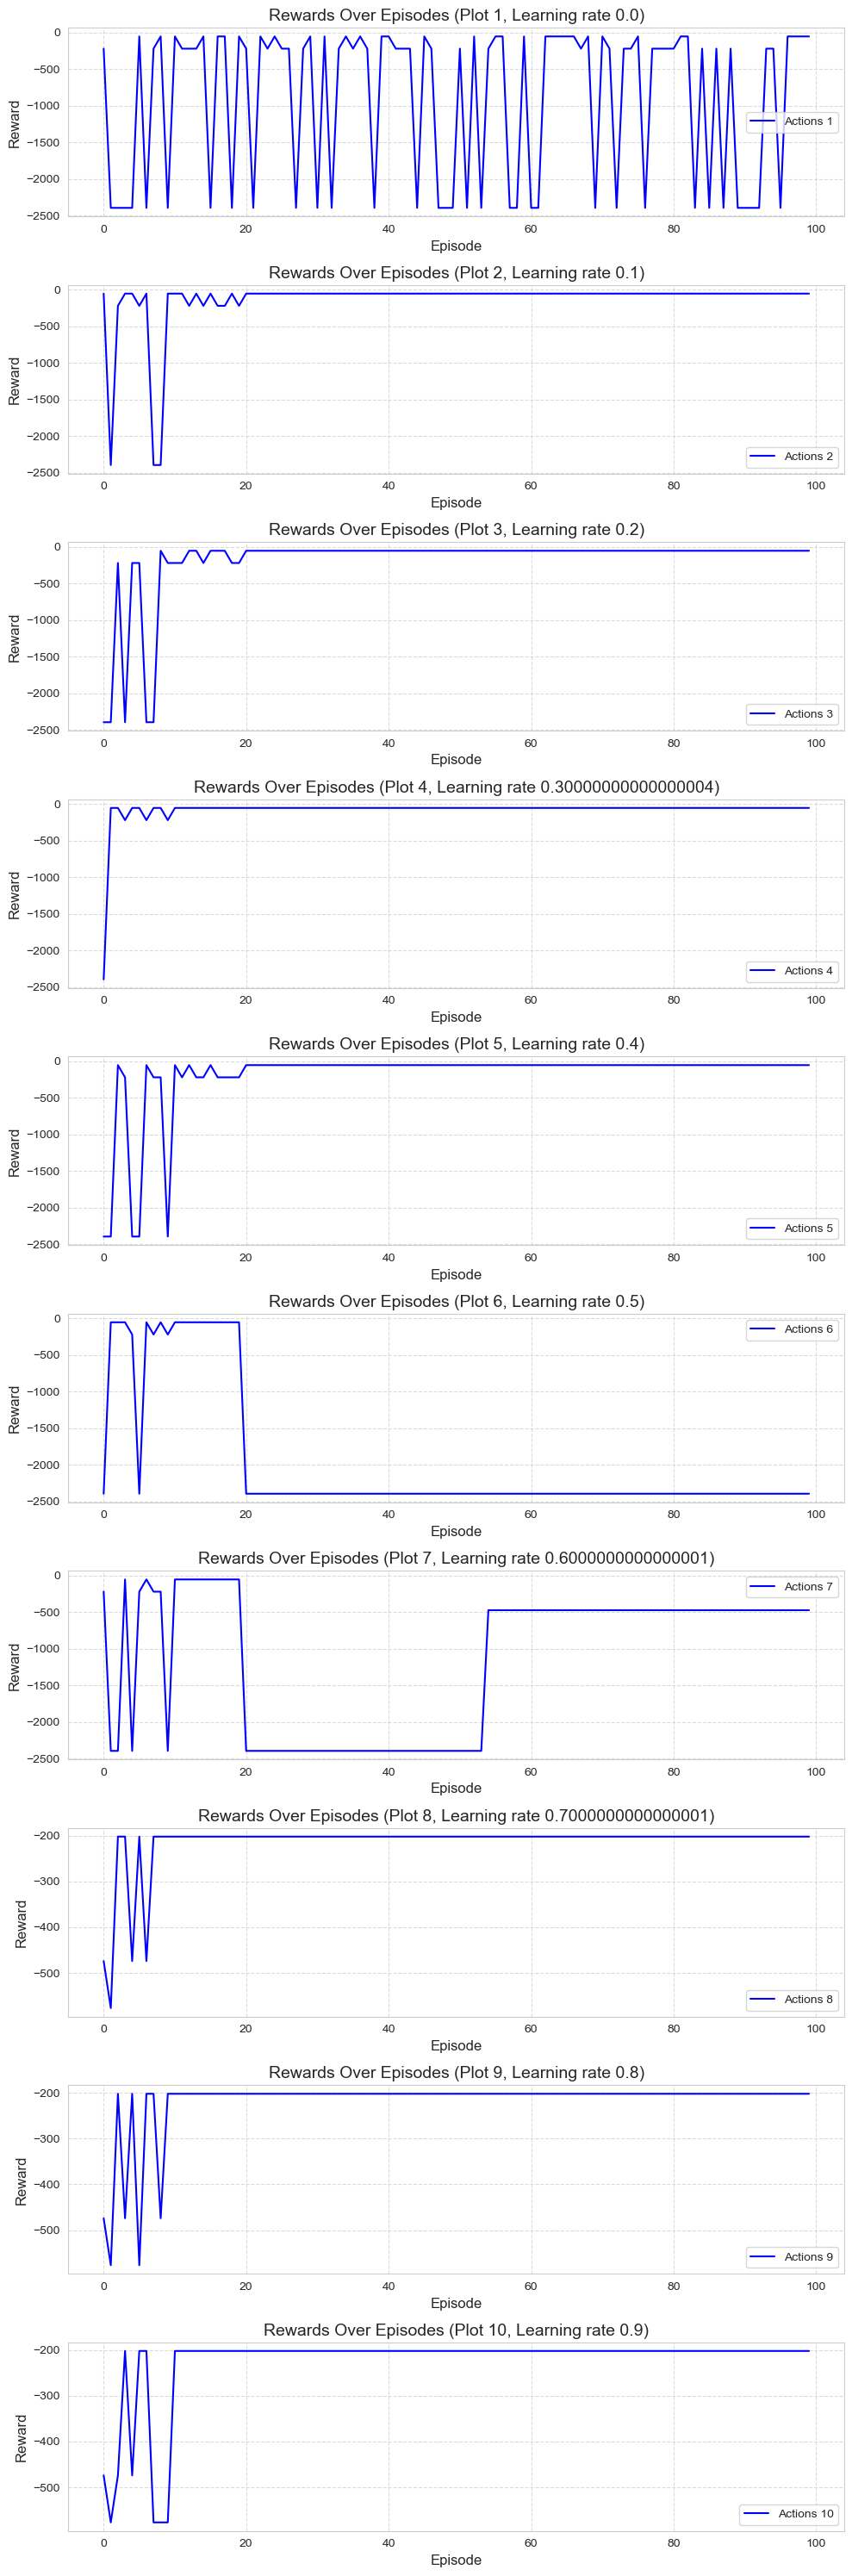

c:\Users\Anastasia\Documents\Milestone-One-Petting-Zoo\environment.py:262: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


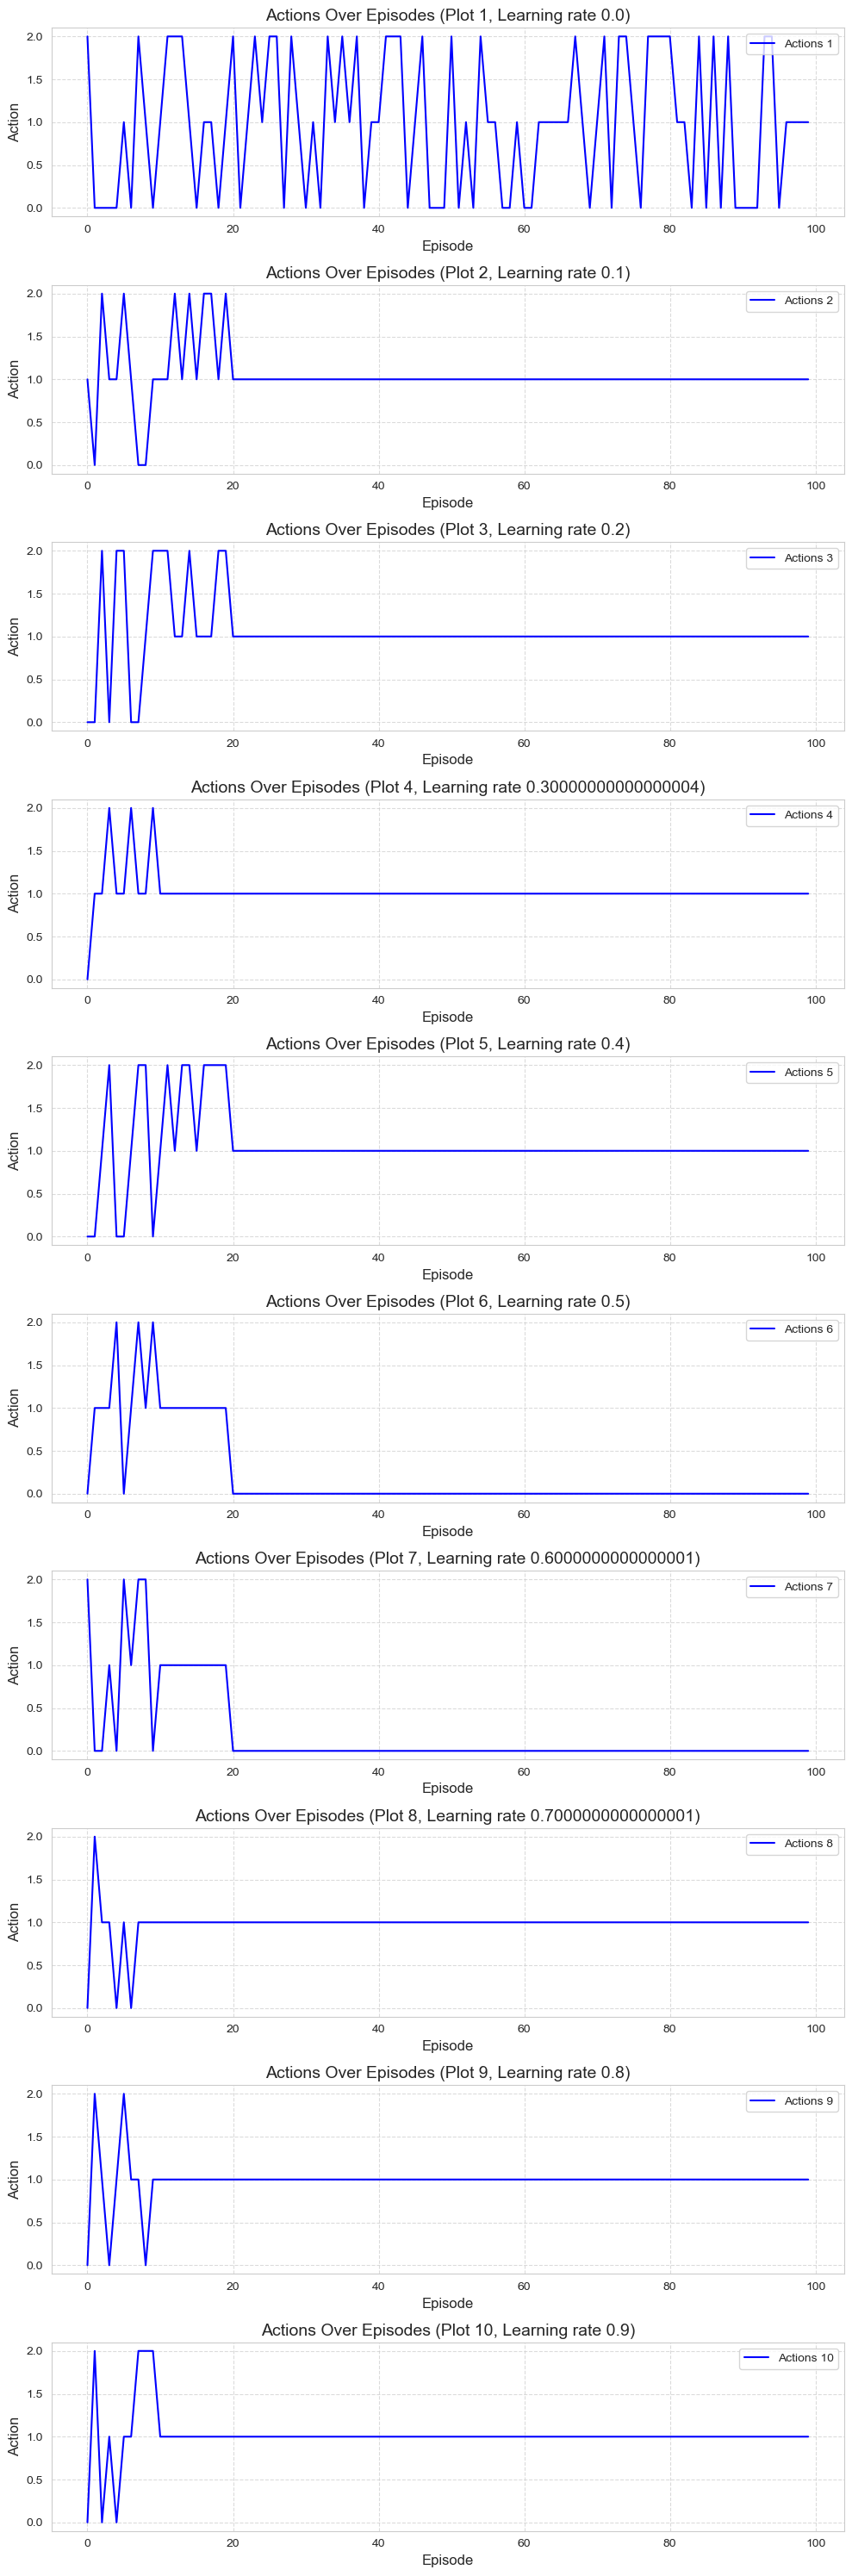

In [8]:
env.close()

## Conclusions

### Learning rate

For the first case, where the learning rate is equal to 0 the agent doesn't seem to converge in 100 timesteps. This can be attributed to the fact that smaller learning rates require more training timesteps given the smaller changes made to the weights each update. This can lead also to getting stuck in a local optima, something that is not happening in our case.

As the learning rate increases, it becomes evident that the agent requires fewer timesteps to converge. However, beyond a learning rate of 0.4, the agent fails to converge to the minimum reward values. This situation poses a potential issue, as rapid convergence to a suboptimal solution may occur.

From the results, it looks like an ideal learning rate value is between 0 and 0.1.